# 🧠 Baseline U-Net + GAN Pix2Pix — Pipeline complet

Ce notebook fait **tout en une seule session Kaggle** :
- **Partie 1** : entraînement du baseline U-Net (10 epochs, ~25 min)
- **Partie 2** : fine-tuning en GAN Pix2Pix initialisé depuis le baseline (15 epochs, ~70 min)
- **Comparaison** baseline vs GAN à la fin

## Environnement
- **Kaggle T4** | **Mixed precision (AMP)** activé
- **Dataset** : `splitted-masked-ffhq-cropped` (part1 + part2, 20k paires)
- Durée totale attendue : **~95-100 min**

## Pourquoi un seul notebook ?
Pour réutiliser **directement les checkpoints du baseline** comme initialisation du générateur GAN, sans avoir à les ré-uploader. Tout reste en mémoire dans `/kaggle/working/` entre les deux phases.

## Plan
**PARTIE 1 — Baseline U-Net (sections 1-12)**
1. Setup
2. Index
3. Dataset/DataLoaders
4. U-Net
5. Loss L1+VGG
6. Métriques PSNR/SSIM
7. Boucle d'entraînement
8-9. Train inpainting + SR
10. Comparaison
11. Sauvegarde
12. Synthèse baseline

**PARTIE 2 — GAN Pix2Pix (sections 13-24)**
13. Install LPIPS + chemins checkpoints
14. Config GAN
15. PatchDiscriminator
16. LPIPS metric (avec fallback)
17. Boucle adversariale
18-19. Train GAN inpainting + SR
20-21. Comparaison baseline vs GAN
22. Visualisations côte-à-côte
23. Sauvegarde GAN
24. Synthèse finale


## 1. Setup Kaggle + imports

In [1]:
import os, sys, time, random, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision.transforms.functional as TF

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch: {torch.__version__}")
print(f"Device : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB)")

PyTorch: 2.10.0+cu128
Device : cuda
GPU    : Tesla T4 (15.6 GB)


In [ ]:
# ─── Paths Kaggle vs local (auto-détection robuste) ───
if Path('/kaggle/input').is_dir():
    # Chemin explicite vers le dataset Kaggle
    DATA_ROOT = Path('/kaggle/input/datasets/ikramelmenhi/dataset/dataset')
    
    # Fallback si le chemin a légèrement changé
    if not DATA_ROOT.exists():
        matches = [c.parent for c in Path('/kaggle/input').rglob('part1') if c.is_dir()]
        if len(matches) > 0:
            DATA_ROOT = matches[0]
            
    OUTPUT_DIR = Path('/kaggle/working')
else:
    # Local (ton poste)
    DATA_ROOT = next((c for c in [
        Path.cwd() / 'dataset', Path.cwd().parent / 'dataset',
        Path.cwd() / 'data' / 'raw', Path.cwd().parent / 'data' / 'raw',
    ] if c.is_dir() and (c/'part1').is_dir()), None)
    OUTPUT_DIR = Path.cwd().parent / 'src' / 'models' / 'checkpoints'

if DATA_ROOT is None or not DATA_ROOT.exists():
    raise ValueError("Dataset introuvable. Ajuste DATA_ROOT manuellement.")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Vérification de la structure (on cherche 'masked' ou 'Masked')
train_dir = DATA_ROOT / 'part1' / 'train'
assert (train_dir / 'masked').is_dir() or (train_dir / 'Masked').is_dir(), \
    f"Structure inattendue dans {DATA_ROOT} — part1/train/masked manquant"

print(f"✓ DATA_ROOT  : {DATA_ROOT}")
print(f"✓ OUTPUT_DIR : {OUTPUT_DIR}")
print(f"✓ Structure validée")

✓ DATA_ROOT  : /kaggle/input/datasets/yyazidd/splitted-masked-ffhq-cropped/dataset
✓ OUTPUT_DIR : /kaggle/working
✓ Structure validée


In [3]:
# ─── Hyperparamètres ───
CONFIG = {
    'train_parts' : ['part1', 'part2'],
    'hr_size'     : 128,
    'lr_size'     : 64,          # pour la tâche SR (2× upscaling)
    'batch_size'  : 32,
    'num_workers' : 2,           # Kaggle T4 recommande 2
    'epochs'      : 10,
    'lr'          : 2e-4,
    'betas'       : (0.5, 0.999),
    'base_ch'     : 32,          # largeur du U-Net (32 → ~8M params)
    'lambda_perc' : 0.1,         # poids de la loss perceptuelle
    'use_amp'     : DEVICE.type == 'cuda',
    'val_subset'  : 500,         # images pour validation rapide en cours d'entraînement
}
for k, v in CONFIG.items():
    print(f"  {k:15} = {v}")

  train_parts     = ['part1', 'part2']
  hr_size         = 128
  lr_size         = 64
  batch_size      = 32
  num_workers     = 2
  epochs          = 10
  lr              = 0.0002
  betas           = (0.5, 0.999)
  base_ch         = 32
  lambda_perc     = 0.1
  use_amp         = True
  val_subset      = 500


## 2. Rechargement de l'index

Si `pairs_index.csv` existe (produit par `02_preprocessing.ipynb`), on le recharge. Sinon on le reconstruit.

In [ ]:
def build_index(data_dir: Path, parts, splits=('train','val','test')) -> pd.DataFrame:
    rows = []
    for part in parts:
        for split in splits:
            split_dir = data_dir / part / split
            # Gestion de la casse (masked vs Masked)
            m_dir = next((d for d in split_dir.iterdir() if d.name.lower() == 'masked' and d.is_dir()), None)
            u_dir = next((d for d in split_dir.iterdir() if d.name.lower() == 'unmasked' and d.is_dir()), None)
            
            if m_dir is None or u_dir is None: continue
            
            m = {p.name: p for p in m_dir.glob('*.png')}
            u = {p.name: p for p in u_dir.glob('*.png')}
            
            for name in sorted(set(m) & set(u)):
                rows.append({'filename': name, 'path_masked': str(m[name]),
                             'path_unmasked': str(u[name]), 'part': part, 'split': split})
    return pd.DataFrame(rows)

# Chercher l'index existant (plusieurs locations possibles)
csv_candidates = [
    Path('/kaggle/input/datasets/ikramelmenhi/dataset-index/dataset_index.csv'),
    Path('/kaggle/working/pairs_index.csv'),
    Path.cwd().parent / 'data' / 'processed' / 'pairs_index.csv',
    Path.cwd() / 'data' / 'processed' / 'pairs_index.csv',
]
idx_csv = next((c for c in csv_candidates if c.is_file()), None)

if idx_csv is not None:
    index_df = pd.read_csv(idx_csv)
    # Important : les chemins peuvent être périmés (machine différente) → on rebuild les paths
    needs_rebuild = not Path(index_df.iloc[0]['path_masked']).is_file()
    if needs_rebuild:
        print(f"⚠️ Chemins du CSV périmés → reconstruction depuis {DATA_ROOT}")
        index_df = build_index(DATA_ROOT, CONFIG['train_parts'])
    else:
        print(f"✓ Index chargé depuis {idx_csv}")
else:
    print(f"⚠️ CSV introuvable → reconstruction depuis {DATA_ROOT}")
    index_df = build_index(DATA_ROOT, CONFIG['train_parts'])

print(f"\n{len(index_df):,} paires indexées")
print(index_df.groupby(['part','split']).size().unstack(fill_value=0))

⚠️ CSV introuvable → reconstruction depuis /kaggle/input/datasets/yyazidd/splitted-masked-ffhq-cropped/dataset

20,000 paires indexées
split  test  train   val
part                    
part1  1000   8000  1000
part2  1000   8000  1000


## 3. Dataset & DataLoaders

Réimport de la classe (copie identique à `02_preprocessing`, pour que ce notebook soit autonome).

In [5]:
class MaskedFaceDataset(Dataset):
    MEAN = [0.5, 0.5, 0.5]
    STD  = [0.5, 0.5, 0.5]
    def __init__(self, df, task='inpainting', lr_size=64, hr_size=128, augment=False):
        assert task in ('inpainting','sr')
        self.df = df.reset_index(drop=True)
        self.task, self.lr_size, self.hr_size, self.augment = task, lr_size, hr_size, augment
        self._norm = transforms.Normalize(self.MEAN, self.STD)
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        m = Image.open(row['path_masked']).convert('RGB')
        u = Image.open(row['path_unmasked']).convert('RGB')
        if m.size != (self.hr_size, self.hr_size): m = m.resize((self.hr_size,)*2, Image.BICUBIC)
        if u.size != (self.hr_size, self.hr_size): u = u.resize((self.hr_size,)*2, Image.BICUBIC)
        if self.augment and random.random() < 0.5:
            m = TF.hflip(m); u = TF.hflip(u)
        if self.task == 'sr':
            m = m.resize((self.lr_size,)*2, Image.BICUBIC)
        return self._norm(TF.to_tensor(m)), self._norm(TF.to_tensor(u))
    @classmethod
    def denormalize(cls, t):
        t = t.clone().cpu()
        for c, (m,s) in enumerate(zip(cls.MEAN, cls.STD)):
            (t[c] if t.ndim==3 else t[:,c]).mul_(s).add_(m)
        return t.clamp(0,1)

def build_dataloaders(index_df, task, cfg):
    loaders = {}
    for split in ['train','val','test']:
        sub = index_df[index_df['split'] == split]
        if len(sub) == 0: continue
        ds = MaskedFaceDataset(sub, task=task, lr_size=cfg['lr_size'],
                               hr_size=cfg['hr_size'], augment=(split=='train'))
        loaders[split] = DataLoader(
            ds, batch_size=cfg['batch_size'],
            shuffle=(split=='train'),
            num_workers=cfg['num_workers'],
            pin_memory=(DEVICE.type=='cuda'),
            drop_last=(split=='train'))
    return loaders

# Test quick shapes
_tmp = build_dataloaders(index_df.head(100), 'sr', CONFIG)
_xb, _yb = next(iter(_tmp['train']))
print(f"✓ SR shapes : x={tuple(_xb.shape)}  y={tuple(_yb.shape)}")
del _tmp, _xb, _yb

✓ SR shapes : x=(32, 3, 64, 64)  y=(32, 3, 128, 128)


## 4. Architecture U-Net

U-Net encodeur-décodeur classique avec 4 niveaux down/up et skip connections. Un `Upsample(scale_factor)` en amont gère la tâche SR sans changer l'architecture du cœur.

In [6]:
def conv_block(in_c, out_c):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
        nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
        nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
        nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
    )

class UNet(nn.Module):
    """U-Net 4-niveaux, output tanh → [-1,1].
    scale_factor > 1 active un pre-upsampling bicubic pour la tâche SR."""
    def __init__(self, in_ch=3, out_ch=3, base=32, scale_factor=1):
        super().__init__()
        self.pre = nn.Upsample(scale_factor=scale_factor, mode='bicubic', align_corners=False) \
                   if scale_factor > 1 else nn.Identity()
        c = base
        self.enc1 = conv_block(in_ch, c)
        self.enc2 = conv_block(c, c*2)
        self.enc3 = conv_block(c*2, c*4)
        self.enc4 = conv_block(c*4, c*8)
        self.bott = conv_block(c*8, c*16)
        self.pool = nn.MaxPool2d(2)
        self.up4, self.dec4 = nn.ConvTranspose2d(c*16, c*8, 2, 2), conv_block(c*16, c*8)
        self.up3, self.dec3 = nn.ConvTranspose2d(c*8, c*4, 2, 2),  conv_block(c*8, c*4)
        self.up2, self.dec2 = nn.ConvTranspose2d(c*4, c*2, 2, 2),  conv_block(c*4, c*2)
        self.up1, self.dec1 = nn.ConvTranspose2d(c*2, c, 2, 2),    conv_block(c*2, c)
        self.final = nn.Conv2d(c, out_ch, 1)
    def forward(self, x):
        x = self.pre(x)
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bott(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], 1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], 1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], 1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], 1))
        return torch.tanh(self.final(d1))

# Sanity check shapes
for task, scale, in_sz in [('inpainting', 1, 128), ('sr', 2, 64)]:
    m = UNet(base=CONFIG['base_ch'], scale_factor=scale).to(DEVICE)
    x = torch.randn(2, 3, in_sz, in_sz, device=DEVICE)
    with torch.no_grad():
        y = m(x)
    n_p = sum(p.numel() for p in m.parameters()) / 1e6
    print(f"  {task:10} scale={scale}  in={tuple(x.shape)}  out={tuple(y.shape)}  params={n_p:.2f}M")
    del m, x, y

  inpainting scale=1  in=(2, 3, 128, 128)  out=(2, 3, 128, 128)  params=7.76M
  sr         scale=2  in=(2, 3, 64, 64)  out=(2, 3, 128, 128)  params=7.76M


## 5. Loss combinée : L1 + Perceptual (VGG16)

Deux composantes :
- **L1** (différence absolue pixel par pixel) — force la fidélité globale des couleurs et formes
- **Perceptual** (distance dans l'espace VGG16 relu3_3) — force la similarité structurelle et pousse le modèle à produire des textures réalistes plutôt que floues

Le VGG16 est pré-entraîné sur ImageNet → figé (`requires_grad=False`).

In [7]:
class VGGPerceptualLoss(nn.Module):
    """Loss L1 sur les features VGG16 relu3_3. Input attendu en [-1,1].
    Fallback automatique sur L1 seul si VGG16 indisponible (pas de réseau)."""
    def __init__(self, layer_idx=15):
        super().__init__()
        self.available = False
        try:
            vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features
            self.slice = nn.Sequential(*list(vgg.children())[:layer_idx+1]).eval()
            for p in self.slice.parameters():
                p.requires_grad = False
            self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1))
            self.register_buffer('std',  torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1))
            self.available = True
            print('  ✓ VGG16 perceptual loss chargée')
        except Exception as e:
            print(f'  ⚠️  VGG16 indisponible ({type(e).__name__}) → fallback L1 seul pour la partie perceptual')
    def _prep(self, x):
        return ((x + 1) / 2 - self.mean) / self.std
    def forward(self, pred, target):
        if not self.available:
            return F.l1_loss(pred, target)  # fallback
        return F.l1_loss(self.slice(self._prep(pred)), self.slice(self._prep(target)))

class CombinedLoss(nn.Module):
    def __init__(self, lambda_perc=0.1):
        super().__init__()
        self.perc = VGGPerceptualLoss()
        self.lambda_perc = lambda_perc
    def forward(self, pred, target):
        l1 = F.l1_loss(pred, target)
        lp = self.perc(pred, target)
        return l1 + self.lambda_perc * lp, {'l1': l1.item(), 'perc': lp.item()}

# Test
criterion = CombinedLoss(CONFIG['lambda_perc']).to(DEVICE)
print(f"✓ Combined loss créée (λ_perc={CONFIG['lambda_perc']})")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 197MB/s]


  ✓ VGG16 perceptual loss chargée
✓ Combined loss créée (λ_perc=0.1)


## 6. Métriques PSNR / SSIM

- **PSNR** (Peak Signal-to-Noise Ratio) : plus haut = mieux, typiquement 20-35 dB en reconstruction. Calculé sur `[-1,1]` donc max_val=2.
- **SSIM** (Structural Similarity) : entre 0 et 1, plus proche de 1 = mieux. Version gaussian-window 11×11.

In [8]:
@torch.no_grad()
def psnr(pred, target, max_val=2.0):
    mse = F.mse_loss(pred, target)
    if mse < 1e-10:
        return torch.tensor(100.0, device=pred.device)
    return 10 * torch.log10(max_val**2 / mse)

def _gaussian_window(size=11, sigma=1.5):
    coords = torch.arange(size, dtype=torch.float32) - size // 2
    g = torch.exp(-(coords**2) / (2 * sigma**2))
    g = g / g.sum()
    return (g.unsqueeze(0) * g.unsqueeze(1))

@torch.no_grad()
def ssim(pred, target, window_size=11, max_val=2.0):
    window = _gaussian_window(window_size).to(pred.device)
    window = window.unsqueeze(0).unsqueeze(0).expand(pred.size(1), 1, -1, -1)
    pad = window_size // 2
    mu1 = F.conv2d(pred, window, padding=pad, groups=pred.size(1))
    mu2 = F.conv2d(target, window, padding=pad, groups=target.size(1))
    mu1_sq, mu2_sq, mu1_mu2 = mu1*mu1, mu2*mu2, mu1*mu2
    s1 = F.conv2d(pred*pred, window, padding=pad, groups=pred.size(1)) - mu1_sq
    s2 = F.conv2d(target*target, window, padding=pad, groups=target.size(1)) - mu2_sq
    s12 = F.conv2d(pred*target, window, padding=pad, groups=pred.size(1)) - mu1_mu2
    C1, C2 = (0.01*max_val)**2, (0.03*max_val)**2
    return (((2*mu1_mu2 + C1)*(2*s12 + C2)) / ((mu1_sq + mu2_sq + C1)*(s1 + s2 + C2))).mean()

# Sanity check
a = torch.randn(2, 3, 64, 64, device=DEVICE)
b = a + 0.1 * torch.randn_like(a)
print(f"✓ PSNR perfect = {psnr(a, a).item():.2f} dB   (~100)")
print(f"✓ SSIM perfect = {ssim(a, a).item():.4f}   (~1.0)")
print(f"✓ PSNR légère perturb = {psnr(a, b).item():.2f} dB   (~26)")
print(f"✓ SSIM légère perturb = {ssim(a, b).item():.4f}    (~0.9)")

✓ PSNR perfect = 100.00 dB   (~100)
✓ SSIM perfect = 1.0000   (~1.0)
✓ PSNR légère perturb = 25.98 dB   (~26)
✓ SSIM légère perturb = 0.9393    (~0.9)


## 7. Boucle d'entraînement

Fonction unique, réutilisable pour les 2 tâches :
- Mixed precision (AMP) si CUDA
- Évaluation partielle à chaque epoch (sur `val_subset` images) pour garder le training rapide
- Sauvegarde du meilleur modèle sur val_psnr
- Logs JSON pour rejouer les courbes après coup

In [1]:
@torch.no_grad()
def evaluate(model, loader, criterion, max_batches=None):
    model.eval()
    tot_loss, tot_psnr, tot_ssim, n = 0.0, 0.0, 0.0, 0
    for i, (xb, yb) in enumerate(loader):
        if max_batches is not None and i >= max_batches: break
        xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
        yh = model(xb)
        loss, _ = criterion(yh, yb)
        tot_loss += loss.item() * xb.size(0)
        tot_psnr += psnr(yh, yb).item() * xb.size(0)
        tot_ssim += ssim(yh, yb).item() * xb.size(0)
        n += xb.size(0)
    return tot_loss/n, tot_psnr/n, tot_ssim/n

def train_model(task, cfg, index_df, verbose=True):
    loaders = build_dataloaders(index_df, task=task, cfg=cfg)
    scale = 2 if task == 'sr' else 1
    model = UNet(base=cfg['base_ch'], scale_factor=scale).to(DEVICE)
    criterion = CombinedLoss(cfg['lambda_perc']).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], betas=cfg['betas'])
    scaler = torch.amp.GradScaler('cuda', enabled=cfg['use_amp'])

    # Pour val rapide, on crée un loader sur un subset
    val_df = index_df[index_df['split'] == 'val'].head(cfg['val_subset'])
    quick_val_ds = MaskedFaceDataset(val_df, task=task, lr_size=cfg['lr_size'],
                                     hr_size=cfg['hr_size'], augment=False)
    quick_val_loader = DataLoader(quick_val_ds, batch_size=cfg['batch_size'],
                                  num_workers=cfg['num_workers'],
                                  pin_memory=(DEVICE.type=='cuda'))

    history = {'epoch': [], 'train_loss': [], 'val_loss': [], 'val_psnr': [], 'val_ssim': [], 'epoch_time': []}
    best_psnr, best_state = -float('inf'), None

    for epoch in range(1, cfg['epochs']+1):
        t0 = time.time()
        model.train()
        running = 0.0; nb = 0
        for xb, yb in loaders['train']:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=cfg['use_amp']):
                yh = model(xb)
                loss, _ = criterion(yh, yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running += loss.item() * xb.size(0); nb += xb.size(0)
        train_loss = running / nb

        val_loss, val_psnr, val_ssim = evaluate(model, quick_val_loader, criterion)
        dt = time.time() - t0

        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_psnr'].append(val_psnr)
        history['val_ssim'].append(val_ssim)
        history['epoch_time'].append(dt)

        is_best = val_psnr > best_psnr
        if is_best:
            best_psnr = val_psnr
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if verbose:
            flag = ' 🔥' if is_best else ''
            print(f"  Epoch {epoch:2d}/{cfg['epochs']}  "
                  f"train={train_loss:.4f}  val={val_loss:.4f}  "
                  f"PSNR={val_psnr:5.2f}dB  SSIM={val_ssim:.4f}  [{dt:5.1f}s]{flag}")

    model.load_state_dict(best_state)
    return model, history

print("✓ train_model() prête")

NameError: name 'torch' is not defined

## 8. Entraînement — tâche `inpainting`

128×128 masked → 128×128 unmasked. ~15 min attendues sur T4.

In [10]:
print("🎨 TÂCHE : INPAINTING\n")
model_inpaint, hist_inpaint = train_model('inpainting', CONFIG, index_df)
print(f"\n✓ Meilleur PSNR (val) : {max(hist_inpaint['val_psnr']):.2f} dB")
print(f"✓ Meilleur SSIM (val) : {max(hist_inpaint['val_ssim']):.4f}")
print(f"✓ Durée totale        : {sum(hist_inpaint['epoch_time'])/60:.1f} min")

🎨 TÂCHE : INPAINTING

  ✓ VGG16 perceptual loss chargée
  Epoch  1/10  train=0.2203  val=0.1570  PSNR=22.11dB  SSIM=0.7296  [112.1s] 🔥
  Epoch  2/10  train=0.1628  val=0.1533  PSNR=22.19dB  SSIM=0.7465  [ 83.6s] 🔥
  Epoch  3/10  train=0.1503  val=0.1333  PSNR=23.32dB  SSIM=0.7719  [ 83.1s] 🔥
  Epoch  4/10  train=0.1430  val=0.1274  PSNR=23.62dB  SSIM=0.7858  [ 83.2s] 🔥
  Epoch  5/10  train=0.1373  val=0.1259  PSNR=23.54dB  SSIM=0.7924  [ 82.8s]
  Epoch  6/10  train=0.1332  val=0.1185  PSNR=24.00dB  SSIM=0.8011  [ 83.4s] 🔥
  Epoch  7/10  train=0.1310  val=0.1201  PSNR=23.87dB  SSIM=0.8008  [ 83.6s]
  Epoch  8/10  train=0.1278  val=0.1212  PSNR=24.00dB  SSIM=0.8039  [ 83.7s] 🔥
  Epoch  9/10  train=0.1262  val=0.1100  PSNR=24.55dB  SSIM=0.8134  [ 83.0s] 🔥
  Epoch 10/10  train=0.1231  val=0.1155  PSNR=23.97dB  SSIM=0.8051  [ 82.8s]

✓ Meilleur PSNR (val) : 24.55 dB
✓ Meilleur SSIM (val) : 0.8134
✓ Durée totale        : 14.4 min


## 9. Entraînement — tâche `sr`

64×64 masked → 128×128 unmasked (super-résolution 2× + inpainting).

In [11]:
print("🔬 TÂCHE : SUPER-RÉSOLUTION + INPAINTING\n")
model_sr, hist_sr = train_model('sr', CONFIG, index_df)
print(f"\n✓ Meilleur PSNR (val) : {max(hist_sr['val_psnr']):.2f} dB")
print(f"✓ Meilleur SSIM (val) : {max(hist_sr['val_ssim']):.4f}")
print(f"✓ Durée totale        : {sum(hist_sr['epoch_time'])/60:.1f} min")

🔬 TÂCHE : SUPER-RÉSOLUTION + INPAINTING

  ✓ VGG16 perceptual loss chargée
  Epoch  1/10  train=0.2179  val=0.1833  PSNR=21.52dB  SSIM=0.7139  [ 83.4s] 🔥
  Epoch  2/10  train=0.1815  val=0.1788  PSNR=21.68dB  SSIM=0.7286  [ 82.7s] 🔥
  Epoch  3/10  train=0.1704  val=0.1574  PSNR=23.22dB  SSIM=0.7530  [ 83.4s] 🔥
  Epoch  4/10  train=0.1645  val=0.1486  PSNR=23.63dB  SSIM=0.7694  [ 83.7s] 🔥
  Epoch  5/10  train=0.1598  val=0.1491  PSNR=23.55dB  SSIM=0.7707  [ 83.6s]
  Epoch  6/10  train=0.1555  val=0.1477  PSNR=23.64dB  SSIM=0.7704  [ 83.7s] 🔥
  Epoch  7/10  train=0.1537  val=0.1416  PSNR=24.12dB  SSIM=0.7803  [ 83.8s] 🔥
  Epoch  8/10  train=0.1507  val=0.1529  PSNR=23.44dB  SSIM=0.7719  [ 83.7s]
  Epoch  9/10  train=0.1488  val=0.1388  PSNR=24.28dB  SSIM=0.7846  [ 83.7s] 🔥
  Epoch 10/10  train=0.1462  val=0.1379  PSNR=24.31dB  SSIM=0.7897  [ 83.7s] 🔥

✓ Meilleur PSNR (val) : 24.31 dB
✓ Meilleur SSIM (val) : 0.7897
✓ Durée totale        : 13.9 min


## 10. Comparaison finale & visualisations

Évaluation **sur le test set complet** (2 000 images jamais vues) pour chaque modèle, plus visualisation côte-à-côte de prédictions.

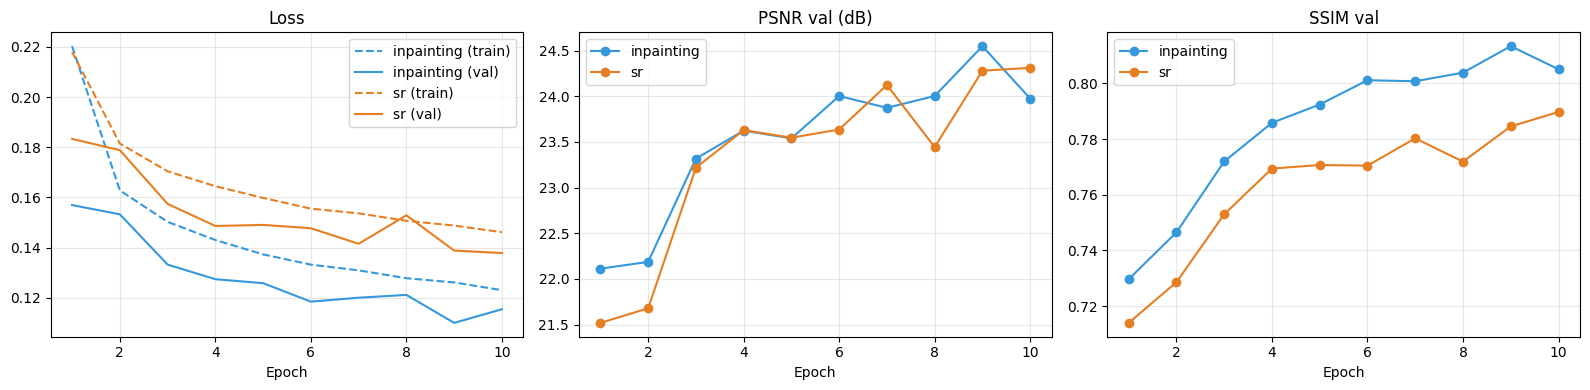

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for name, hist, color in [('inpainting', hist_inpaint, '#3498db'), ('sr', hist_sr, '#e67e22')]:
    axes[0].plot(hist['epoch'], hist['train_loss'], label=f'{name} (train)', color=color, linestyle='--')
    axes[0].plot(hist['epoch'], hist['val_loss'],   label=f'{name} (val)',   color=color)
    axes[1].plot(hist['epoch'], hist['val_psnr'], label=name, color=color, marker='o')
    axes[2].plot(hist['epoch'], hist['val_ssim'], label=name, color=color, marker='o')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('PSNR val (dB)'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].set_title('SSIM val'); axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [13]:
# Évaluation sur le test complet
criterion = CombinedLoss(CONFIG['lambda_perc']).to(DEVICE)

test_results = {}
for task, model in [('inpainting', model_inpaint), ('sr', model_sr)]:
    loaders = build_dataloaders(index_df, task=task, cfg=CONFIG)
    loss, p, s = evaluate(model, loaders['test'], criterion)
    test_results[task] = {'loss': loss, 'psnr': p, 'ssim': s}
    print(f"  {task:10} | loss={loss:.4f}  PSNR={p:.2f}dB  SSIM={s:.4f}")

df_res = pd.DataFrame(test_results).T
df_res.columns = ['Test Loss', 'Test PSNR (dB)', 'Test SSIM']
print("\n📊 Résultats sur le test set (2 000 images) :")
print(df_res.round(4).to_string())

  ✓ VGG16 perceptual loss chargée
  inpainting | loss=0.1106  PSNR=24.35dB  SSIM=0.8144
  sr         | loss=0.1379  PSNR=24.22dB  SSIM=0.7919

📊 Résultats sur le test set (2 000 images) :
            Test Loss  Test PSNR (dB)  Test SSIM
inpainting     0.1106         24.3472     0.8144
sr             0.1379         24.2202     0.7919


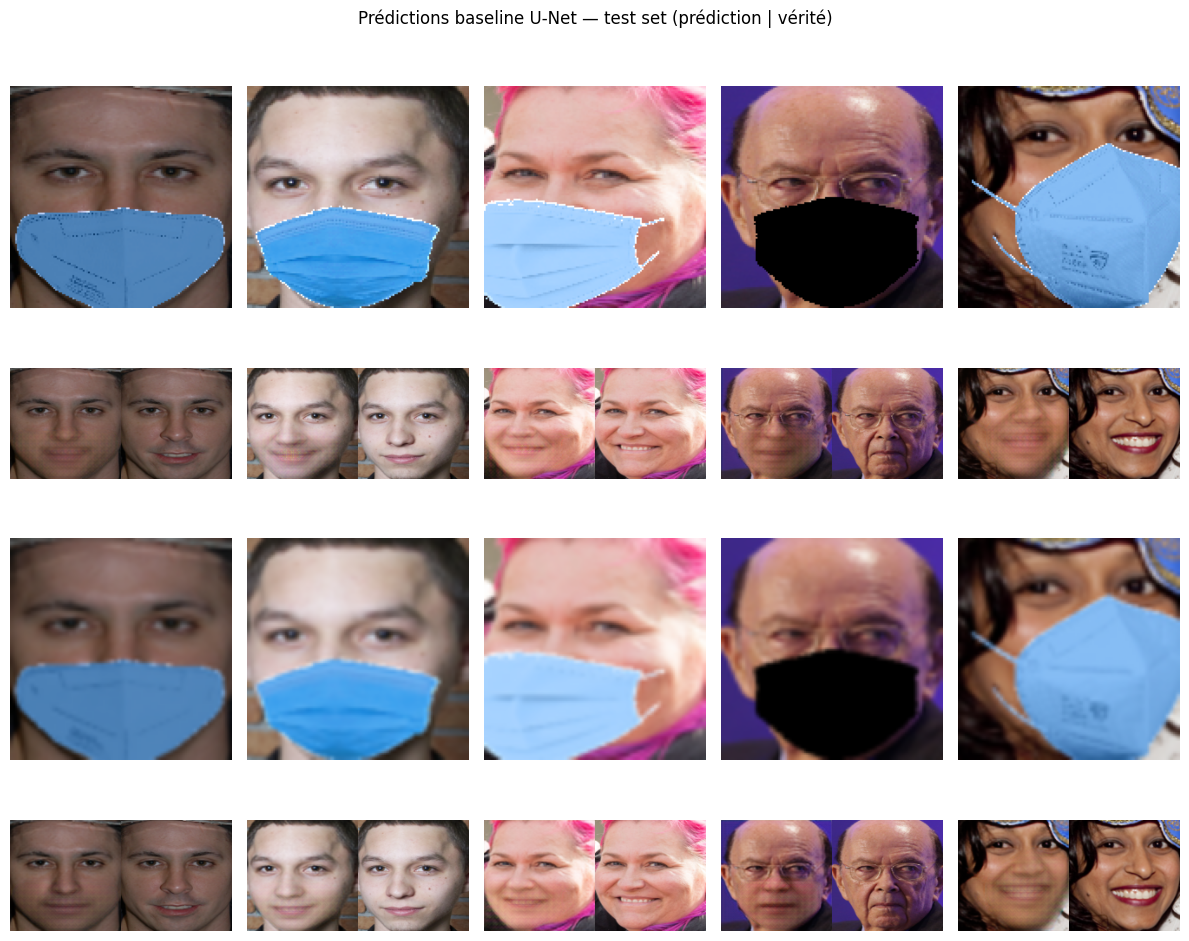

In [14]:
# Visualisation qualitative : 5 exemples du test set par tâche
def to_plot(t):
    return MaskedFaceDataset.denormalize(t).permute(1,2,0).numpy()

n_show = 5
fig, axes = plt.subplots(4, n_show, figsize=(2.4*n_show, 10))

for row_task, (task, model) in enumerate([('inpainting', model_inpaint), ('sr', model_sr)]):
    test_df = index_df[index_df['split']=='test'].sample(n_show, random_state=SEED).reset_index(drop=True)
    ds = MaskedFaceDataset(test_df, task=task, lr_size=CONFIG['lr_size'], hr_size=CONFIG['hr_size'])
    model.eval()
    with torch.no_grad():
        for i in range(n_show):
            x, y = ds[i]
            yh = model(x.unsqueeze(0).to(DEVICE)).squeeze(0).cpu()
            r_in = row_task * 2
            r_pred = row_task * 2 + 1
            # Si SR, on upsample l'input pour affichage cohérent
            x_show = TF.resize(x, [CONFIG['hr_size']]*2, antialias=True) if task=='sr' else x
            axes[r_in, i].imshow(to_plot(x_show)); axes[r_in, i].axis('off')
            axes[r_pred, i].imshow(np.concatenate([to_plot(yh), to_plot(y)], axis=1))
            axes[r_pred, i].axis('off')
            if i == 0:
                axes[r_in, i].set_ylabel(f'{task}\ninput', rotation=0, labelpad=40, fontsize=10)
                axes[r_pred, i].set_ylabel(f'{task}\npred | target', rotation=0, labelpad=40, fontsize=10)

plt.suptitle('Prédictions baseline U-Net — test set (prédiction | vérité)', y=1.01)
plt.tight_layout(); plt.show()

## 11. Sauvegarde des checkpoints

Les poids + la config + l'historique pour pouvoir reprendre ou évaluer plus tard sans ré-entraîner.

In [15]:
for task, model, hist in [('inpainting', model_inpaint, hist_inpaint),
                           ('sr',        model_sr,      hist_sr)]:
    ckpt_path = OUTPUT_DIR / f'unet_{task}_best.pt'
    torch.save({
        'task'    : task,
        'config'  : CONFIG,
        'state'   : model.state_dict(),
        'history' : hist,
        'test'    : test_results[task],
    }, ckpt_path)
    size_mb = ckpt_path.stat().st_size / 1e6
    print(f"✓ {ckpt_path.name} sauvé ({size_mb:.1f} MB)")

# Historique combiné en JSON (léger, lisible)
with open(OUTPUT_DIR / 'training_summary.json', 'w') as f:
    json.dump({
        'config'  : CONFIG,
        'inpainting': {'history': hist_inpaint, 'test': test_results['inpainting']},
        'sr'      : {'history': hist_sr,      'test': test_results['sr']},
    }, f, indent=2, default=str)
print(f"✓ training_summary.json sauvé")

✓ unet_inpainting_best.pt sauvé (31.1 MB)
✓ unet_sr_best.pt sauvé (31.1 MB)
✓ training_summary.json sauvé


## 12. Synthèse

In [16]:
print("="*65)
print("📋 BASELINE U-NET — RÉSULTATS")
print("="*65)
print(f"\n▸ Config : {CONFIG['epochs']} epochs, batch={CONFIG['batch_size']}, lr={CONFIG['lr']}")
print(f"▸ Paires train/val/test : {(index_df['split']=='train').sum():,} / {(index_df['split']=='val').sum():,} / {(index_df['split']=='test').sum():,}")
print(f"\n▸ RÉSULTATS TEST SET")
print(df_res.round(4).to_string())

# Diagnostic
inp_psnr, sr_psnr = test_results['inpainting']['psnr'], test_results['sr']['psnr']
inp_ssim, sr_ssim = test_results['inpainting']['ssim'], test_results['sr']['ssim']
print(f"\n▸ INTERPRÉTATION")
if inp_psnr > sr_psnr + 1:
    print(f"   • Inpainting > SR de {inp_psnr-sr_psnr:.2f} dB — attendu (SR a la tâche supplémentaire du 2× upscaling)")
elif sr_psnr > inp_psnr + 1:
    print(f"   • SR > inpainting de {sr_psnr-inp_psnr:.2f} dB — surprenant, à investiguer")
else:
    print(f"   • Performances comparables (écart {abs(inp_psnr-sr_psnr):.2f} dB)")

if inp_psnr < 22:
    print("   ⚠️  PSNR faible → le modèle sous-apprend. Pistes : +epochs, +capacité, loss plus agressive")
elif inp_psnr < 28:
    print("   ✓ PSNR correct pour un baseline — marge nette pour GAN/diffusion")
else:
    print("   ✓ PSNR élevé — le baseline est solide, GAN apportera surtout du réalisme perceptuel")

print(f"\n▸ PROCHAINES ÉTAPES POSSIBLES")
print("   A. GAN : ajouter un discriminateur PatchGAN → meilleur réalisme (textures peau)")
print("   B. Diffusion : DDPM conditionné sur masked → état-de-l'art mais lent")
print("   C. Améliorer le baseline : +epochs, LR scheduling, more augmentations")

📋 BASELINE U-NET — RÉSULTATS

▸ Config : 10 epochs, batch=32, lr=0.0002
▸ Paires train/val/test : 16,000 / 2,000 / 2,000

▸ RÉSULTATS TEST SET
            Test Loss  Test PSNR (dB)  Test SSIM
inpainting     0.1106         24.3472     0.8144
sr             0.1379         24.2202     0.7919

▸ INTERPRÉTATION
   • Performances comparables (écart 0.13 dB)
   ✓ PSNR correct pour un baseline — marge nette pour GAN/diffusion

▸ PROCHAINES ÉTAPES POSSIBLES
   A. GAN : ajouter un discriminateur PatchGAN → meilleur réalisme (textures peau)
   B. Diffusion : DDPM conditionné sur masked → état-de-l'art mais lent
   C. Améliorer le baseline : +epochs, LR scheduling, more augmentations


---

# ════════════════════════════════════════════════════
# PARTIE 2 : GAN PIX2PIX (fine-tuning du baseline)
# ════════════════════════════════════════════════════

Maintenant que le baseline U-Net est entraîné et sauvegardé dans `/kaggle/working/`, on enchaîne avec le GAN. **Tout reste en mémoire** : `index_df`, `MaskedFaceDataset`, `UNet`, `VGGPerceptualLoss`, métriques PSNR/SSIM... on ne redéfinit que ce qui est nouveau.

## Stratégie GAN
- **Générateur G** : U-Net **initialisé avec les poids du baseline** (transfer learning → démarre déjà à 24 dB)
- **Discriminateur D** : **PatchGAN 70×70**
- **Loss G** : `1·L1 + 0.1·VGG + 0.01·adv`
- **Loss D** : LSGAN (MSE)
- **Sélection** : meilleur **LPIPS** (qualité perceptuelle, pas PSNR)


## 13. Setup GAN — install LPIPS + localisation des checkpoints

In [17]:
# Install LPIPS si nécessaire
import subprocess, sys
try:
    import lpips
    print(f"✓ lpips déjà installé")
except ImportError:
    print("Installation de lpips...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "lpips"])
    import lpips
    print("✓ lpips installé")


Installation de lpips...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 1.5 MB/s eta 0:00:00
✓ lpips installé


In [18]:
# Localisation des checkpoints baseline produits par la PARTIE 1
ckpt_candidates = list(OUTPUT_DIR.glob("unet_*_best.pt"))
def find_ckpt(task):
    matches = [c for c in ckpt_candidates if task in c.name]
    return sorted(matches, key=lambda p: p.stat().st_mtime, reverse=True)[0] if matches else None

BASELINE_CKPT = {
    "inpainting": find_ckpt("inpainting"),
    "sr"        : find_ckpt("sr"),
}
for t, p in BASELINE_CKPT.items():
    print(f"  {t:10} : {p}")

assert all(BASELINE_CKPT.values()), (
    "❌ Checkpoints baseline introuvables ! "
    "Vérifie que la PARTIE 1 a bien fini sans erreur."
)
print("\n✓ Checkpoints baseline trouvés — prêts pour le fine-tuning GAN")


  inpainting : /kaggle/working/unet_inpainting_best.pt
  sr         : /kaggle/working/unet_sr_best.pt

✓ Checkpoints baseline trouvés — prêts pour le fine-tuning GAN


## 14. Configuration GAN

Nouveau dictionnaire `CONFIG_GAN` pour ne pas écraser celui du baseline.

In [19]:
CONFIG_GAN = {
    "train_parts" : ["part1", "part2"],
    "hr_size"     : 128,
    "lr_size"     : 64,
    "batch_size"  : 32,
    "num_workers" : 2,
    "epochs"      : 15,
    # Generator (fine-tune depuis baseline → LR plus bas)
    "lr_g"        : 1e-4,
    "betas"       : (0.5, 0.999),
    "base_ch_g"   : 32,
    # Discriminator
    "lr_d"        : 2e-4,
    "base_ch_d"   : 64,
    # Loss weights
    "lambda_l1"   : 1.0,
    "lambda_perc" : 0.1,
    "lambda_adv"  : 0.01,
    # Misc
    "use_amp"     : DEVICE.type == "cuda",
    "val_subset"  : 500,
}
for k, v in CONFIG_GAN.items():
    print(f"  {k:15} = {v}")


  train_parts     = ['part1', 'part2']
  hr_size         = 128
  lr_size         = 64
  batch_size      = 32
  num_workers     = 2
  epochs          = 15
  lr_g            = 0.0001
  betas           = (0.5, 0.999)
  base_ch_g       = 32
  lr_d            = 0.0002
  base_ch_d       = 64
  lambda_l1       = 1.0
  lambda_perc     = 0.1
  lambda_adv      = 0.01
  use_amp         = True
  val_subset      = 500


## 15. PatchDiscriminator

Réseau convolutif qui produit une **carte de décision 14×14** au lieu d'un scalaire unique. Chaque patch de ~70×70 de l'image d'origine est jugé indépendamment (vrai/faux) → le G est obligé de réussir **partout localement**, pas juste globalement.

In [20]:
class PatchDiscriminator(nn.Module):
    """PatchGAN 70×70 conditionnel : D(input_masked, target_or_generated) → patch map 14×14.
    Si input est LR (tâche SR), upscale à la taille de la target avant concat."""
    def __init__(self, in_channels=6, base=64):
        super().__init__()
        def block(i, o, s=2, n=True):
            L = [nn.Conv2d(i, o, 4, s, 1, bias=not n)]
            if n: L.append(nn.BatchNorm2d(o))
            L.append(nn.LeakyReLU(0.2, True))
            return nn.Sequential(*L)
        self.net = nn.Sequential(
            block(in_channels, base, n=False),  # 128 → 64
            block(base, base*2),                # 64 → 32
            block(base*2, base*4),              # 32 → 16
            block(base*4, base*8, s=1),         # 16 → 15
            nn.Conv2d(base*8, 1, 4, 1, 1),      # 15 → 14 (patch map)
        )
    def forward(self, inp, out):
        if inp.shape[-1] != out.shape[-1]:
            inp = F.interpolate(inp, size=out.shape[-2:], mode="bicubic", align_corners=False)
        return self.net(torch.cat([inp, out], dim=1))

# Sanity check
for task, scale, in_sz in [("inpainting", 1, 128), ("sr", 2, 64)]:
    D_test = PatchDiscriminator(base=CONFIG_GAN["base_ch_d"]).to(DEVICE)
    G_test = UNet(base=CONFIG_GAN["base_ch_g"], scale_factor=scale).to(DEVICE)
    x = torch.randn(2, 3, in_sz, in_sz, device=DEVICE)
    with torch.no_grad():
        y_fake = G_test(x)
        d_out = D_test(x, y_fake)
    pd_ = sum(p.numel() for p in D_test.parameters())/1e6
    print(f"  {task:10} D={pd_:.2f}M params | D({tuple(x.shape)},{tuple(y_fake.shape)}) → {tuple(d_out.shape)}")
    del D_test, G_test, x, y_fake, d_out


  inpainting D=2.77M params | D((2, 3, 128, 128),(2, 3, 128, 128)) → (2, 1, 14, 14)
  sr         D=2.77M params | D((2, 3, 64, 64),(2, 3, 128, 128)) → (2, 1, 14, 14)


## 16. LPIPS — métrique perceptuelle

**LPIPS** (Learned Perceptual Image Patch Similarity) : une distance apprise dans l'espace des features VGG/AlexNet, calibrée sur des préférences humaines. Plus elle est basse, plus deux images sont **perceptuellement similaires**.

C'est la métrique-clé pour les GAN : un GAN peut perdre 1-2 dB de PSNR mais gagner 0.05 de LPIPS, ce qui se voit nettement à l'œil nu.

In [21]:
# Chargement LPIPS — fallback sur VGG perceptual si réseau indisponible
print("Chargement LPIPS AlexNet...")
try:
    lpips_fn = lpips.LPIPS(net="alex", verbose=False).to(DEVICE).eval()
    for p in lpips_fn.parameters(): p.requires_grad = False
    LPIPS_AVAILABLE = True
    print("  ✓ LPIPS AlexNet chargé")
except Exception as e:
    print(f"  ⚠️ LPIPS indisponible ({type(e).__name__}) → fallback sur VGG")
    LPIPS_AVAILABLE = False
    lpips_fn = None

_fallback_perc = None
@torch.no_grad()
def lpips_metric(pred, target):
    if LPIPS_AVAILABLE:
        return lpips_fn(pred, target).mean()
    global _fallback_perc
    if _fallback_perc is None:
        _fallback_perc = VGGPerceptualLoss().to(DEVICE).eval()
    return _fallback_perc(pred, target)

# Test
a = torch.randn(2, 3, 128, 128, device=DEVICE)
b = a + 0.1 * torch.randn_like(a)
print(f"  LPIPS perfect/noisy : {lpips_metric(a,a):.4f} / {lpips_metric(a,b):.4f}")


Chargement LPIPS AlexNet...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 207MB/s]


  ✓ LPIPS AlexNet chargé
  LPIPS perfect/noisy : 0.0000 / 0.0030


## 17. Boucle d'entraînement adversariale

Pour chaque batch :
1. **Step D** : `D(real)→1`, `D(fake.detach())→0` (le `.detach()` empêche les gradients de remonter dans G)
2. **Step G** : minimise `L1 + perceptual + λ_adv · MSE(D(fake), 1)`

Sélection du meilleur epoch sur **min(LPIPS)**, pas sur PSNR.

In [22]:
@torch.no_grad()
def evaluate_gan(G, loader, max_batches=None):
    G.eval()
    tot_l1, tot_psnr, tot_ssim, tot_lpips, n = 0., 0., 0., 0., 0
    for i, (xb, yb) in enumerate(loader):
        if max_batches is not None and i >= max_batches: break
        xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
        yh = G(xb)
        bs = xb.size(0)
        tot_l1    += F.l1_loss(yh, yb).item() * bs
        tot_psnr  += psnr(yh, yb).item() * bs
        tot_ssim  += ssim(yh, yb).item() * bs
        tot_lpips += lpips_metric(yh, yb).item() * bs
        n += bs
    return tot_l1/n, tot_psnr/n, tot_ssim/n, tot_lpips/n

def train_gan(task, cfg, index_df, baseline_ckpt=None, verbose=True):
    loaders = build_dataloaders(index_df, task=task, cfg=cfg)
    scale = 2 if task == "sr" else 1
    
    # === Générateur initialisé depuis baseline ===
    G = UNet(base=cfg["base_ch_g"], scale_factor=scale).to(DEVICE)
    if baseline_ckpt is not None and baseline_ckpt.is_file():
        ckpt = torch.load(baseline_ckpt, map_location=DEVICE, weights_only=False)
        G.load_state_dict(ckpt["state"])
        print(f"  ✓ G initialisé depuis {baseline_ckpt.name}")
    else:
        print(f"  ⚠️ G initialisé from-scratch (pas de checkpoint)")
    
    # === Discriminateur ===
    D = PatchDiscriminator(base=cfg["base_ch_d"]).to(DEVICE)
    
    # === Losses & optimizers ===
    perc_fn = VGGPerceptualLoss().to(DEVICE)
    opt_G = torch.optim.Adam(G.parameters(), lr=cfg["lr_g"], betas=cfg["betas"])
    opt_D = torch.optim.Adam(D.parameters(), lr=cfg["lr_d"], betas=cfg["betas"])
    scaler_G = torch.amp.GradScaler("cuda", enabled=cfg["use_amp"])
    scaler_D = torch.amp.GradScaler("cuda", enabled=cfg["use_amp"])
    
    # Quick val
    val_df = index_df[index_df["split"] == "val"].head(cfg["val_subset"])
    qv_ds = MaskedFaceDataset(val_df, task=task, lr_size=cfg["lr_size"], hr_size=cfg["hr_size"])
    qv_loader = DataLoader(qv_ds, batch_size=cfg["batch_size"],
                           num_workers=cfg["num_workers"], pin_memory=(DEVICE.type=="cuda"))
    
    history = {"epoch":[], "loss_g":[], "loss_d":[], "loss_l1":[], "loss_adv":[],
               "val_psnr":[], "val_ssim":[], "val_lpips":[], "epoch_time":[]}
    best_lpips, best_state = float("inf"), None
    
    for epoch in range(1, cfg["epochs"]+1):
        t0 = time.time()
        G.train(); D.train()
        sum_g, sum_d, sum_l1, sum_adv, nb = 0., 0., 0., 0., 0
        
        for xb, yb in loaders["train"]:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            bs = xb.size(0)
            
            # ===== Step D =====
            opt_D.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=cfg["use_amp"]):
                with torch.no_grad():
                    yh = G(xb)
                d_real = D(xb, yb)
                d_fake = D(xb, yh.detach())
                loss_d = 0.5 * (F.mse_loss(d_real, torch.ones_like(d_real)) +
                                F.mse_loss(d_fake, torch.zeros_like(d_fake)))
            scaler_D.scale(loss_d).backward()
            scaler_D.step(opt_D)
            scaler_D.update()
            
            # ===== Step G =====
            opt_G.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=cfg["use_amp"]):
                yh = G(xb)
                loss_l1   = F.l1_loss(yh, yb)
                loss_perc = perc_fn(yh, yb)
                d_fake_g  = D(xb, yh)
                loss_adv  = F.mse_loss(d_fake_g, torch.ones_like(d_fake_g))
                loss_g = (cfg["lambda_l1"] * loss_l1 +
                          cfg["lambda_perc"] * loss_perc +
                          cfg["lambda_adv"] * loss_adv)
            scaler_G.scale(loss_g).backward()
            scaler_G.step(opt_G)
            scaler_G.update()
            
            sum_g += loss_g.item()*bs; sum_d += loss_d.item()*bs
            sum_l1 += loss_l1.item()*bs; sum_adv += loss_adv.item()*bs
            nb += bs
        
        l1v, psnrv, ssimv, lpipsv = evaluate_gan(G, qv_loader)
        dt = time.time() - t0
        
        history["epoch"].append(epoch)
        history["loss_g"].append(sum_g/nb); history["loss_d"].append(sum_d/nb)
        history["loss_l1"].append(sum_l1/nb); history["loss_adv"].append(sum_adv/nb)
        history["val_psnr"].append(psnrv); history["val_ssim"].append(ssimv)
        history["val_lpips"].append(lpipsv); history["epoch_time"].append(dt)
        
        is_best = lpipsv < best_lpips
        if is_best:
            best_lpips = lpipsv
            best_state = {k: v.detach().cpu().clone() for k, v in G.state_dict().items()}
        
        if verbose:
            flag = " 🔥" if is_best else ""
            print(f"  Ep {epoch:2d}/{cfg['epochs']}  G={sum_g/nb:.4f}(l1={sum_l1/nb:.4f},adv={sum_adv/nb:.3f}) "
                  f"D={sum_d/nb:.4f}  PSNR={psnrv:5.2f}  SSIM={ssimv:.3f}  LPIPS={lpipsv:.3f}  [{dt:.0f}s]{flag}")
    
    G.load_state_dict(best_state)
    return G, D, history

print("✓ train_gan() prête")


✓ train_gan() prête


## 18. Entraînement GAN — `inpainting`

~32 min sur T4.

In [23]:
print("🎨 GAN — INPAINTING\n")
G_inpaint, D_inpaint, hist_inpaint_gan = train_gan(
    "inpainting", CONFIG_GAN, index_df, baseline_ckpt=BASELINE_CKPT["inpainting"])
print(f"\n✓ Meilleur LPIPS (val) : {min(hist_inpaint_gan['val_lpips']):.4f}")
print(f"✓ PSNR correspondant   : {hist_inpaint_gan['val_psnr'][np.argmin(hist_inpaint_gan['val_lpips'])]:.2f} dB")
print(f"✓ Durée totale          : {sum(hist_inpaint_gan['epoch_time'])/60:.1f} min")


🎨 GAN — INPAINTING

  ✓ G initialisé depuis unet_inpainting_best.pt
  ✓ VGG16 perceptual loss chargée
  Ep  1/15  G=0.1243(l1=0.0662,adv=0.348) D=0.2623  PSNR=24.70  SSIM=0.820  LPIPS=0.077  [121s] 🔥
  Ep  2/15  G=0.1264(l1=0.0658,adv=0.469) D=0.2011  PSNR=24.10  SSIM=0.810  LPIPS=0.068  [120s] 🔥
  Ep  3/15  G=0.1272(l1=0.0658,adv=0.521) D=0.2376  PSNR=24.68  SSIM=0.824  LPIPS=0.065  [120s] 🔥
  Ep  4/15  G=0.1258(l1=0.0646,adv=0.504) D=0.1849  PSNR=24.09  SSIM=0.816  LPIPS=0.056  [120s] 🔥
  Ep  5/15  G=0.1262(l1=0.0646,adv=0.518) D=0.1921  PSNR=23.74  SSIM=0.814  LPIPS=0.055  [121s] 🔥
  Ep  6/15  G=0.1244(l1=0.0637,adv=0.490) D=0.2530  PSNR=24.87  SSIM=0.827  LPIPS=0.062  [120s]
  Ep  7/15  G=0.1191(l1=0.0612,adv=0.401) D=0.2057  PSNR=23.86  SSIM=0.806  LPIPS=0.053  [121s] 🔥
  Ep  8/15  G=0.1205(l1=0.0612,adv=0.459) D=0.2074  PSNR=23.31  SSIM=0.810  LPIPS=0.055  [121s]
  Ep  9/15  G=0.1223(l1=0.0621,adv=0.486) D=0.1981  PSNR=24.24  SSIM=0.822  LPIPS=0.052  [121s] 🔥
  Ep 10/15  G=0.1212

## 19. Entraînement GAN — `sr`

~30 min sur T4.

In [24]:
print("🔬 GAN — SUPER-RÉSOLUTION + INPAINTING\n")
G_sr, D_sr, hist_sr_gan = train_gan(
    "sr", CONFIG_GAN, index_df, baseline_ckpt=BASELINE_CKPT["sr"])
print(f"\n✓ Meilleur LPIPS (val) : {min(hist_sr_gan['val_lpips']):.4f}")
print(f"✓ PSNR correspondant   : {hist_sr_gan['val_psnr'][np.argmin(hist_sr_gan['val_lpips'])]:.2f} dB")
print(f"✓ Durée totale          : {sum(hist_sr_gan['epoch_time'])/60:.1f} min")


🔬 GAN — SUPER-RÉSOLUTION + INPAINTING

  ✓ G initialisé depuis unet_sr_best.pt
  ✓ VGG16 perceptual loss chargée
  Ep  1/15  G=0.1459(l1=0.0694,adv=0.365) D=0.2704  PSNR=24.54  SSIM=0.796  LPIPS=0.085  [121s] 🔥
  Ep  2/15  G=0.1464(l1=0.0680,adv=0.472) D=0.2072  PSNR=24.13  SSIM=0.794  LPIPS=0.073  [121s] 🔥
  Ep  3/15  G=0.1489(l1=0.0687,adv=0.532) D=0.1855  PSNR=24.09  SSIM=0.793  LPIPS=0.064  [121s] 🔥
  Ep  4/15  G=0.1504(l1=0.0689,adv=0.557) D=0.1777  PSNR=23.99  SSIM=0.789  LPIPS=0.060  [121s] 🔥
  Ep  5/15  G=0.1505(l1=0.0684,adv=0.576) D=0.1769  PSNR=23.87  SSIM=0.785  LPIPS=0.060  [121s] 🔥
  Ep  6/15  G=0.1517(l1=0.0687,adv=0.637) D=0.2141  PSNR=24.09  SSIM=0.792  LPIPS=0.062  [122s]
  Ep  7/15  G=0.1455(l1=0.0663,adv=0.485) D=0.1856  PSNR=23.92  SSIM=0.785  LPIPS=0.058  [121s] 🔥
  Ep  8/15  G=0.1497(l1=0.0676,adv=0.582) D=0.1725  PSNR=23.86  SSIM=0.784  LPIPS=0.058  [121s]
  Ep  9/15  G=0.1464(l1=0.0658,adv=0.573) D=0.2705  PSNR=24.32  SSIM=0.798  LPIPS=0.064  [121s]
  Ep 10/15 

## 20. Comparaison baseline vs GAN sur le test set

Évaluation sur les 2 000 images test pour les **4 modèles** : baseline + GAN × inpainting + sr.

In [25]:
results_full = {}

# GAN results (just trained)
for task, G in [("inpainting", G_inpaint), ("sr", G_sr)]:
    loaders = build_dataloaders(index_df, task=task, cfg=CONFIG_GAN)
    l1v, psnrv, ssimv, lpipsv = evaluate_gan(G, loaders["test"])
    results_full[(task, "GAN")] = {"l1": l1v, "psnr": psnrv, "ssim": ssimv, "lpips": lpipsv}

# Baseline results (reload checkpoints and re-eval to get LPIPS too)
for task in ["inpainting", "sr"]:
    ckpt = torch.load(BASELINE_CKPT[task], map_location=DEVICE, weights_only=False)
    scale = 2 if task == "sr" else 1
    G_base = UNet(base=CONFIG_GAN["base_ch_g"], scale_factor=scale).to(DEVICE)
    G_base.load_state_dict(ckpt["state"])
    loaders = build_dataloaders(index_df, task=task, cfg=CONFIG_GAN)
    l1v, psnrv, ssimv, lpipsv = evaluate_gan(G_base, loaders["test"])
    results_full[(task, "baseline")] = {"l1": l1v, "psnr": psnrv, "ssim": ssimv, "lpips": lpipsv}
    del G_base

df_full = pd.DataFrame(results_full).T
df_full.index = pd.MultiIndex.from_tuples(df_full.index, names=["task","model"])
df_full = df_full[["psnr","ssim","lpips","l1"]].round(4)
print("\n📊 RÉSULTATS TEST SET (2 000 images)\n")
print(df_full.to_string())

print("\n🔺 Delta GAN - baseline (↑ PSNR/SSIM mieux,  ↓ LPIPS mieux)")
for task in ["inpainting", "sr"]:
    b, g = results_full[(task,"baseline")], results_full[(task,"GAN")]
    print(f"  {task:10}  ΔPSNR={g['psnr']-b['psnr']:+.2f}  ΔSSIM={g['ssim']-b['ssim']:+.3f}  ΔLPIPS={g['lpips']-b['lpips']:+.3f}")



📊 RÉSULTATS TEST SET (2 000 images)

                        psnr    ssim   lpips      l1
task       model                                    
inpainting GAN       24.3608  0.8219  0.0492  0.0529
sr         GAN       23.9851  0.7880  0.0546  0.0647
inpainting baseline  24.3472  0.8144  0.0873  0.0564
sr         baseline  24.2202  0.7919  0.0898  0.0648

🔺 Delta GAN - baseline (↑ PSNR/SSIM mieux,  ↓ LPIPS mieux)
  inpainting  ΔPSNR=+0.01  ΔSSIM=+0.008  ΔLPIPS=-0.038
  sr          ΔPSNR=-0.24  ΔSSIM=-0.004  ΔLPIPS=-0.035


## 21. Courbes d'apprentissage GAN

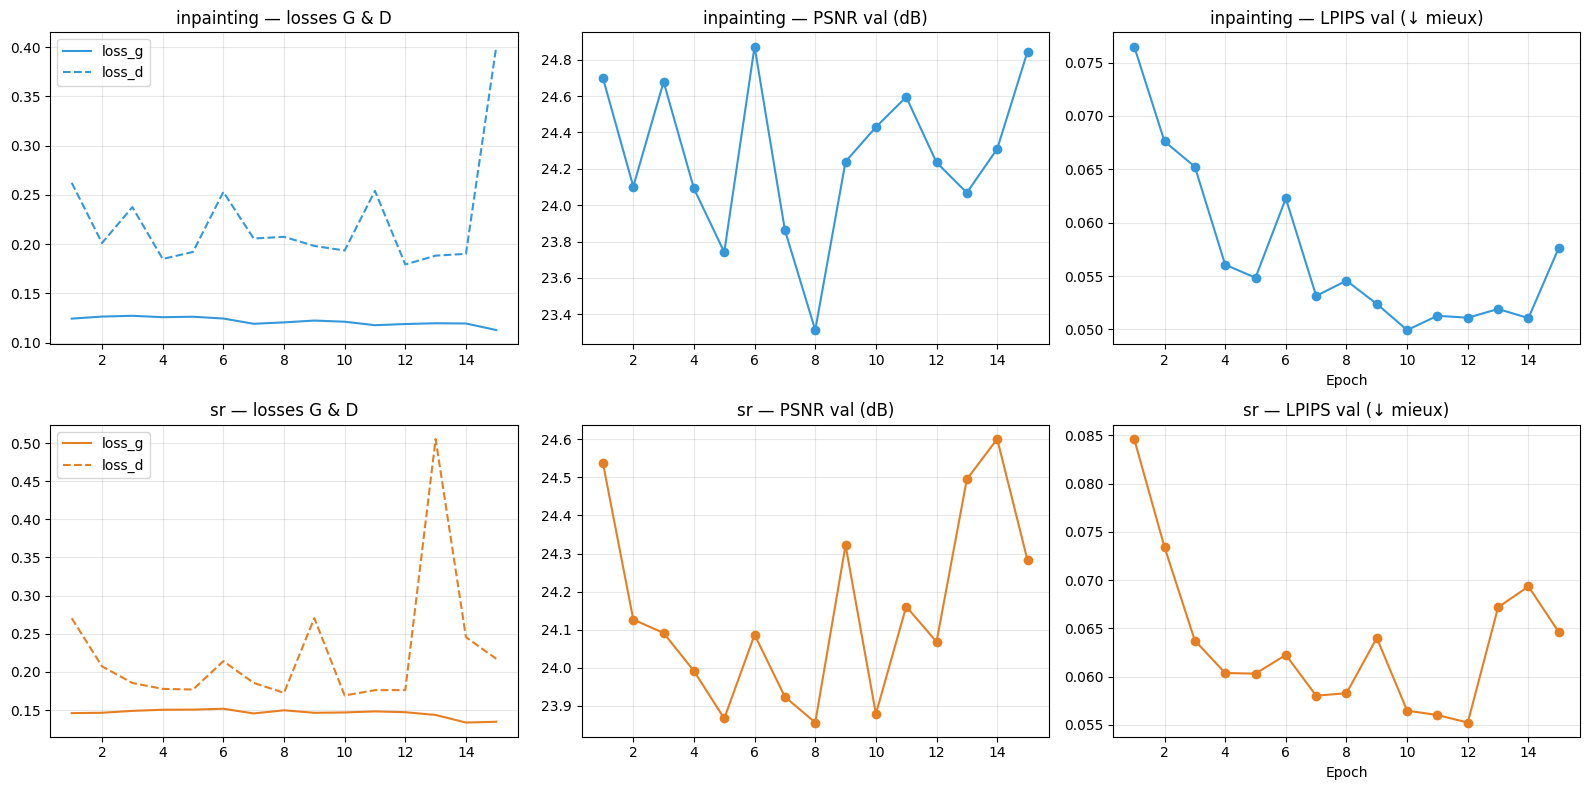

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for row, (name, hist, col) in enumerate([("inpainting", hist_inpaint_gan, "#3498db"),
                                          ("sr",         hist_sr_gan,      "#e67e22")]):
    axes[row, 0].plot(hist["epoch"], hist["loss_g"], label="loss_g", color=col)
    axes[row, 0].plot(hist["epoch"], hist["loss_d"], label="loss_d", color=col, linestyle="--")
    axes[row, 0].set_title(f"{name} — losses G & D"); axes[row, 0].legend(); axes[row, 0].grid(alpha=0.3)
    
    axes[row, 1].plot(hist["epoch"], hist["val_psnr"], color=col, marker="o")
    axes[row, 1].set_title(f"{name} — PSNR val (dB)"); axes[row, 1].grid(alpha=0.3)
    
    axes[row, 2].plot(hist["epoch"], hist["val_lpips"], color=col, marker="o")
    axes[row, 2].set_title(f"{name} — LPIPS val (↓ mieux)")
    axes[row, 2].set_xlabel("Epoch"); axes[row, 2].grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 22. Visualisations côte-à-côte : input | baseline | GAN | target

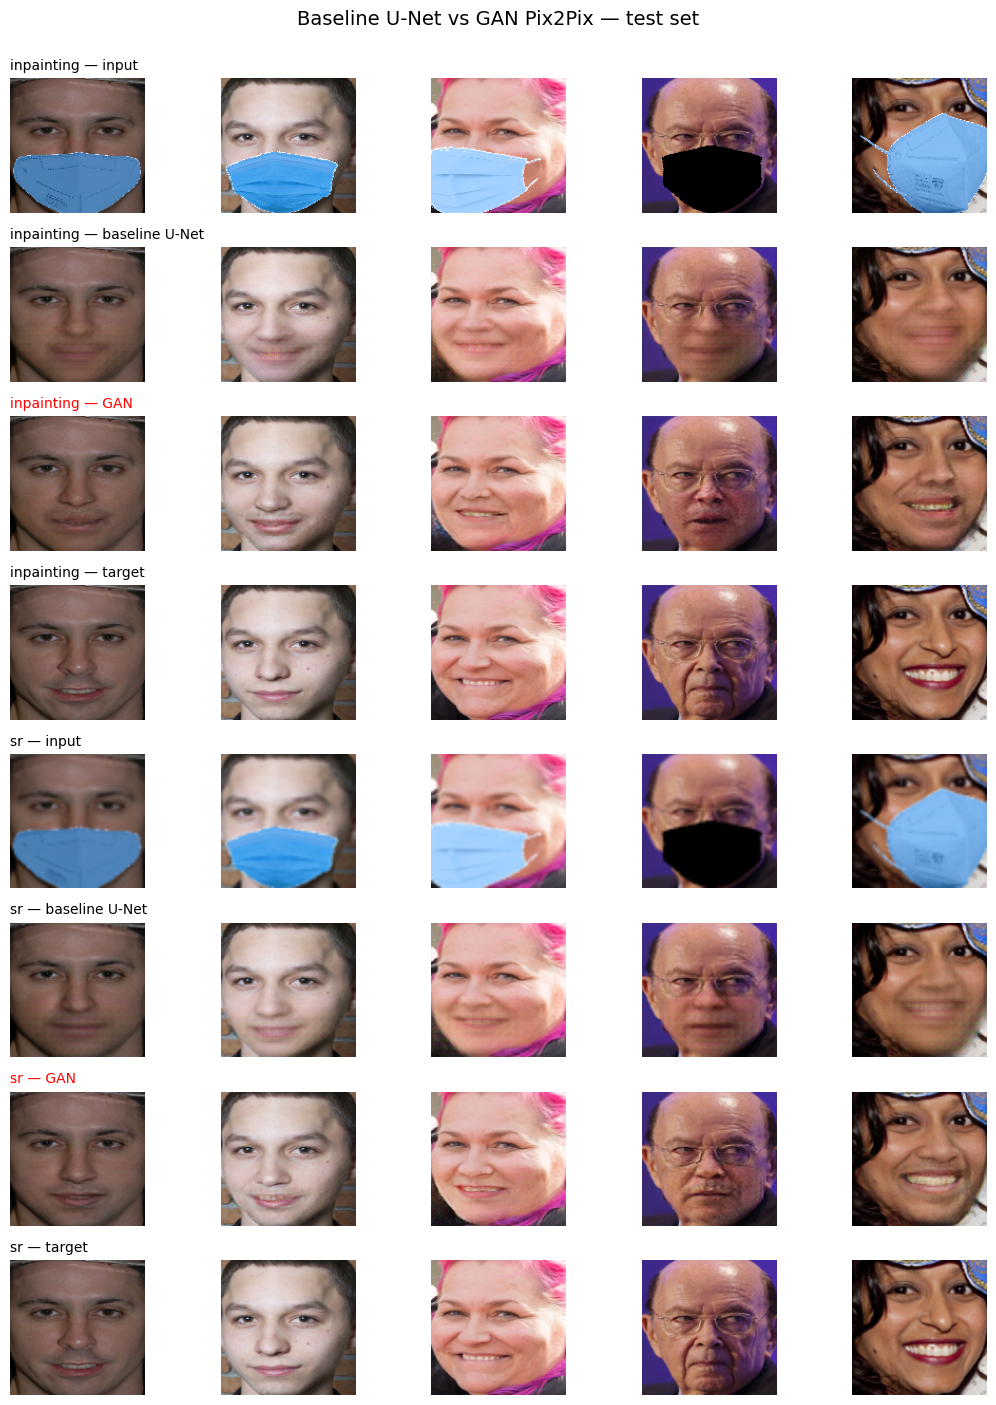

In [27]:
def to_plot(t):
    return MaskedFaceDataset.denormalize(t).permute(1,2,0).numpy()

n_show = 5
fig, axes = plt.subplots(8, n_show, figsize=(2.2*n_show, 14))

for row_pair, (task, G_gan) in enumerate([("inpainting", G_inpaint), ("sr", G_sr)]):
    scale = 2 if task == "sr" else 1
    G_base = UNet(base=CONFIG_GAN["base_ch_g"], scale_factor=scale).to(DEVICE).eval()
    G_base.load_state_dict(torch.load(BASELINE_CKPT[task], map_location=DEVICE, weights_only=False)["state"])
    
    test_df = index_df[index_df["split"]=="test"].sample(n_show, random_state=SEED).reset_index(drop=True)
    ds = MaskedFaceDataset(test_df, task=task, lr_size=CONFIG_GAN["lr_size"], hr_size=CONFIG_GAN["hr_size"])
    G_gan.eval()
    
    with torch.no_grad():
        for i in range(n_show):
            x, y = ds[i]
            x_d = x.unsqueeze(0).to(DEVICE)
            y_gan  = G_gan(x_d).squeeze(0).cpu()
            y_base = G_base(x_d).squeeze(0).cpu()
            x_show = TF.resize(x, [CONFIG_GAN["hr_size"]]*2, antialias=True) if task == "sr" else x
            
            r0 = row_pair * 4
            axes[r0+0, i].imshow(to_plot(x_show));  axes[r0+0, i].axis("off")
            axes[r0+1, i].imshow(to_plot(y_base));  axes[r0+1, i].axis("off")
            axes[r0+2, i].imshow(to_plot(y_gan));   axes[r0+2, i].axis("off")
            axes[r0+3, i].imshow(to_plot(y));       axes[r0+3, i].axis("off")
            if i == 0:
                axes[r0+0, i].set_title(f"{task} — input", loc="left", fontsize=10)
                axes[r0+1, i].set_title(f"{task} — baseline U-Net", loc="left", fontsize=10)
                axes[r0+2, i].set_title(f"{task} — GAN", loc="left", fontsize=10, color="red")
                axes[r0+3, i].set_title(f"{task} — target", loc="left", fontsize=10)
    del G_base

plt.suptitle("Baseline U-Net vs GAN Pix2Pix — test set", fontsize=14, y=1.00)
plt.tight_layout(); plt.show()


## 23. Sauvegarde des modèles GAN

In [28]:
for task, G, D, hist in [("inpainting", G_inpaint, D_inpaint, hist_inpaint_gan),
                          ("sr",        G_sr,      D_sr,      hist_sr_gan)]:
    ckpt_path = OUTPUT_DIR / f"gan_{task}_best.pt"
    torch.save({
        "task"    : task,
        "config"  : CONFIG_GAN,
        "state_G" : G.state_dict(),
        "state_D" : D.state_dict(),
        "history" : hist,
        "test"    : results_full.get((task, "GAN")),
    }, ckpt_path)
    print(f"✓ {ckpt_path.name} ({ckpt_path.stat().st_size/1e6:.1f} MB)")

# JSON consolidé
final_summary = {
    "config_baseline" : CONFIG,
    "config_gan"      : CONFIG_GAN,
    "results"         : {f"{t}/{m}": v for (t,m), v in results_full.items()},
    "history_baseline": {"inpainting": hist_inpaint, "sr": hist_sr},
    "history_gan"     : {"inpainting": hist_inpaint_gan, "sr": hist_sr_gan},
}
with open(OUTPUT_DIR / "final_summary.json", "w") as f:
    json.dump(final_summary, f, indent=2, default=str)
print(f"✓ final_summary.json sauvegardé")

# Liste finale des fichiers produits
print(f"\n📂 Fichiers dans {OUTPUT_DIR}:")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"   {f.name:35} {f.stat().st_size/1e6:.1f} MB")


✓ gan_inpainting_best.pt (42.2 MB)
✓ gan_sr_best.pt (42.2 MB)
✓ final_summary.json sauvegardé

📂 Fichiers dans /kaggle/working:
   __notebook__.ipynb                  3.6 MB
   final_summary.json                  0.0 MB
   gan_inpainting_best.pt              42.2 MB
   gan_sr_best.pt                      42.2 MB
   training_summary.json               0.0 MB
   unet_inpainting_best.pt             31.1 MB
   unet_sr_best.pt                     31.1 MB


## 24. Synthèse finale

In [29]:
print("="*70)
print("📋 PIPELINE COMPLET — BASELINE U-NET + GAN PIX2PIX")
print("="*70)

print(f"\n▸ DURÉES")
print(f"   Baseline inpainting : {sum(hist_inpaint['epoch_time'])/60:.1f} min")
print(f"   Baseline sr         : {sum(hist_sr['epoch_time'])/60:.1f} min")
print(f"   GAN inpainting      : {sum(hist_inpaint_gan['epoch_time'])/60:.1f} min")
print(f"   GAN sr              : {sum(hist_sr_gan['epoch_time'])/60:.1f} min")
tot = (sum(hist_inpaint['epoch_time']) + sum(hist_sr['epoch_time']) +
       sum(hist_inpaint_gan['epoch_time']) + sum(hist_sr_gan['epoch_time'])) / 60
print(f"   Total              : {tot:.1f} min")

print(f"\n▸ RÉSULTATS TEST")
print(df_full.to_string())

print(f"\n▸ INTERPRÉTATION")
for task in ["inpainting", "sr"]:
    b, g = results_full[(task,"baseline")], results_full[(task,"GAN")]
    d_psnr = g["psnr"] - b["psnr"]
    d_lpips = g["lpips"] - b["lpips"]
    print(f"\n  📌 {task.upper()}")
    if d_lpips < -0.01:
        print(f"     ✓ LPIPS amélioré de {abs(d_lpips):.3f} → textures plus réalistes")
    elif d_lpips > 0.01:
        print(f"     ⚠️  LPIPS dégradé de {d_lpips:.3f} → GAN peut-être pas convergé")
    if d_psnr < -0.3:
        print(f"     • PSNR baissé de {abs(d_psnr):.2f} dB (compromis attendu : réalisme > fidélité pixel)")
    elif d_psnr > 0.3:
        print(f"     ✓ PSNR amélioré de {d_psnr:.2f} dB (bonus rare)")

print(f"\n▸ PROCHAINES ÉTAPES POSSIBLES")
print("   A. Évaluation qualitative humaine (MOS) sur ~50 exemples")
print("   B. Diffusion : DDPM conditionné → état-de-l'art mais lent en inférence")
print("   C. Optimisations : LR scheduling, augmentations agressives, spectral norm sur D")


📋 PIPELINE COMPLET — BASELINE U-NET + GAN PIX2PIX

▸ DURÉES
   Baseline inpainting : 14.4 min
   Baseline sr         : 13.9 min
   GAN inpainting      : 30.1 min
   GAN sr              : 30.3 min
   Total              : 88.7 min

▸ RÉSULTATS TEST
                        psnr    ssim   lpips      l1
task       model                                    
inpainting GAN       24.3608  0.8219  0.0492  0.0529
sr         GAN       23.9851  0.7880  0.0546  0.0647
inpainting baseline  24.3472  0.8144  0.0873  0.0564
sr         baseline  24.2202  0.7919  0.0898  0.0648

▸ INTERPRÉTATION

  📌 INPAINTING
     ✓ LPIPS amélioré de 0.038 → textures plus réalistes

  📌 SR
     ✓ LPIPS amélioré de 0.035 → textures plus réalistes

▸ PROCHAINES ÉTAPES POSSIBLES
   A. Évaluation qualitative humaine (MOS) sur ~50 exemples
   B. Diffusion : DDPM conditionné → état-de-l'art mais lent en inférence
   C. Optimisations : LR scheduling, augmentations agressives, spectral norm sur D
